In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../defibrillation")   # add parent directory to Python path
import functions
from pathlib import Path
from tensorflow import keras
import csv

In [121]:
import numpy as np
import matplotlib.pyplot as plt

def get_currents(file):
    def read_currents_file(filepath):
        # Read the file content
        with open(filepath, 'r') as file:
            # Read the first line to get current names
            header_line = file.readline().strip()
            
            # Split the header first by semicolons, then by commas
            current_groups = header_line.split(';')
            current_names = []
            for group in current_groups:
                currents = [name.strip() for name in group.split(',')]
                current_names.extend(currents)
                
            # Initialize dictionary with empty lists for each current
            data_dict = {name: [] for name in current_names}
            
            # Read the rest of the lines
            for line in file:
                if not line.strip():  # Skip empty lines
                    continue
                
                # Split values by semicolon first, then comma
                value_groups = line.strip().split(';')
                values = []
                for group in value_groups:
                    group_values = [float(val.strip()) for val in group.split(',') if val.strip()]
                    values.extend(group_values)
                
                # Add each value to corresponding current's list
                for name, value in zip(current_names, values):
                    data_dict[name].append(value)
        
        # Convert lists to numpy arrays for easier manipulation
        for name in data_dict:
            data_dict[name] = np.array(data_dict[name])
        
        return data_dict

    # Example usage:
    filepath = file
    currents_data = read_currents_file(filepath)
    for current_name in currents_data.keys():
        print(f" - {current_name}")
    return currents_data

def readFile(file):
    currents_data = get_currents(file)
    mask =  -100< currents_data['voltage']
    if 'NA' in currents_data:
        del currents_data['NA']
    matrix = np.zeros((len(currents_data['voltage'][mask]),len(currents_data)-1))  # Exclude voltage
    # assign currents to matrix columns
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name not in ['voltage']:
            matrix[:, i - (1 if 'voltage' in currents_data else 0)] = values[mask]
    U, S, V = np.linalg.svd(matrix)
    def projection_S(v):
        ps = [0] * len(S)
        for i in [3,5,6,7,8,9,10,11]:
            ps += np.inner(v,V[i]) / np.inner(V[i],V[i]) * V[i]
        return ps
    identifiability = {}
    for i, (current_name, values) in enumerate(currents_data.items()):
        if current_name in ['voltage']:
            continue
        v_I = [0]*len(S)
        v_I[i-1] = 1
        k = np.linalg.norm(v_I-projection_S(v_I))
        identifiability[current_name] = k
    sorted_identifiability = dict(sorted(identifiability.items(), key=lambda item: item[1], reverse=True))
    return U,S,V,currents_data,sorted_identifiability
def plot_sorted_currents_with_identifiability(currents_data, sorted_identifiability):
    # Get currents in sorted order (already sorted by identifiability)
    currents_to_plot = list(sorted_identifiability.keys())
    n_currents = len(currents_to_plot)
    
    # Create figure with special grid
    fig = plt.figure(figsize=(15, 4*(n_currents//3 + 2)))  # +2 for voltage row
    
    # Create grid with different row heights
    gs = plt.GridSpec(n_currents//3 + 2, 3, height_ratios=[1.5] + [1]*(n_currents//3 + 1))
    
    # Plot voltage across entire first row
    ax_voltage = fig.add_subplot(gs[0, :])
    ax_voltage.plot(currents_data['voltage'], 'b-')
    ax_voltage.set_title('Voltage')
    ax_voltage.set_ylabel('mV')
    ax_voltage.set_xlabel('Time Step')
    ax_voltage.grid(True)
    
    # Plot currents in remaining grid
    for idx, current_name in enumerate(currents_to_plot):
        row = (idx // 3) + 1  # +1 because voltage took first row
        col = idx % 3
        ax = fig.add_subplot(gs[row, col])
        
        # Plot the current
        ax.plot(currents_data[current_name], 'b-')
        
        # Set title with identifiability value
        identifiability_value = sorted_identifiability[current_name]
        def format_current_name(name):
            # Dictionary for special current name formatting
            current_formats = {
                'INa': 'I_{Na}',
                'ICaL': 'I_{CaL}',
                'Ito': 'I_{to}',
                'IKr': 'I_{Kr}',
                'IKs': 'I_{Ks}',
                'IK1': 'I_{K1}',
                'INaCa': 'I_{NaCa}',
                'INaK': 'I_{NaK}',
                'INab': 'I_{Nab}',
                'ICab': 'I_{Cab}',
                'IKb': 'I_{Kb}',
                'IpCa': 'I_{pCa}',
                'INalate': 'I_{Na,late}'
            }
            return current_formats.get(name, name)  # Return formatted name or original if not in dictionary

        # Then modify the title setting line to:
        ax.set_title(f'${format_current_name(current_name)}$\nIdentifiability: {identifiability_value:.3f}',fontsize=20)        
        ax.set_ylabel('Current (pA/pF)')
        ax.set_xlabel('Time Step')
        ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('currents_sorted_by_identifiability.png', dpi=300)
    plt.show()
U,S,V,currents_data, sorted_identifiability = readFile('currents_ovvr_TNNP.csv')
print(S,V)  

 - voltage
 - INa
 - Ito
 - ICaL
 - IKs
 - IpK
 - INaK
 - IKr
 - INaCa
 - IK1
 - IbCa
 - IpCa
 - IbNa
[4.02106921e+02 7.69282702e+01 4.05513819e+01 2.66055641e+01
 1.62906864e+01 9.06692929e+00 7.28710503e+00 3.23430599e+00
 2.20961213e+00 5.28892001e-01 6.66299125e-02 5.21564018e-03] [[ 9.99995499e-01 -9.73705363e-04  2.45566821e-03 -1.45389310e-05
  -3.61843690e-04 -1.14589851e-03 -4.02583922e-05 -4.94085408e-05
  -6.98716327e-04  2.75113909e-04 -7.16399270e-05  8.08263744e-05]
 [ 2.71211664e-03  5.60226925e-01 -7.85056106e-01  1.20930632e-01
   1.68030140e-01  1.37576365e-01  8.26655290e-02 -1.18006889e-02
   1.13594063e-02 -2.13482101e-02  2.10709723e-02 -6.17509725e-03]
 [ 6.65094828e-04 -7.60275995e-01 -3.77217242e-01  3.36877001e-01
   2.06380172e-01  2.74107802e-01  1.44736800e-01 -1.14808270e-01
   9.38319650e-02 -5.36878438e-02  4.84335528e-02 -1.76304830e-02]
 [ 4.65319307e-04  1.76136556e-01  1.86305252e-01 -2.55783991e-02
  -1.08618274e-01  2.36561776e-01  2.14926183e-01 -

In [123]:
def get_voltage(vec,epsilon):
    path = Path(f"./data/voltage_vector{vec}_epsilon_{epsilon}_measure_dt_4.csv")
    voltage = np.array([])
    with open(path) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=';')
        for row in csv_reader:
            voltage = np.append(voltage, float(row[1]))
    return voltage

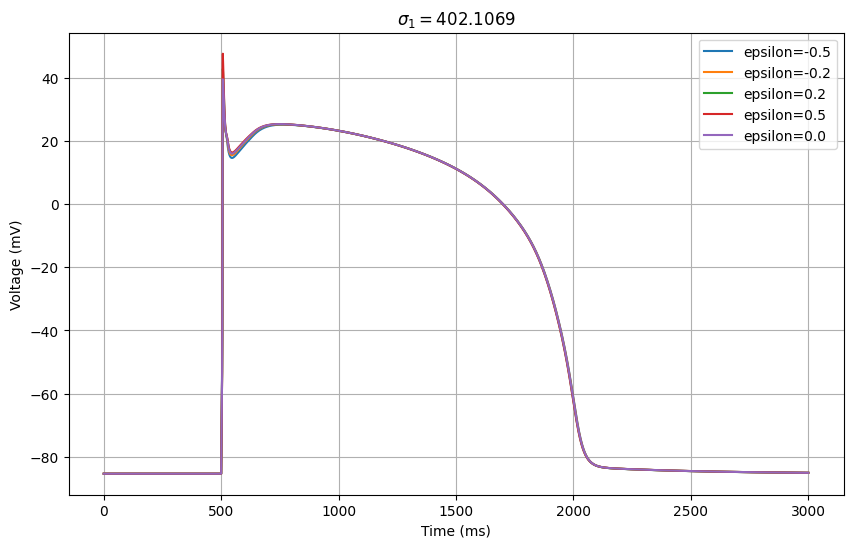

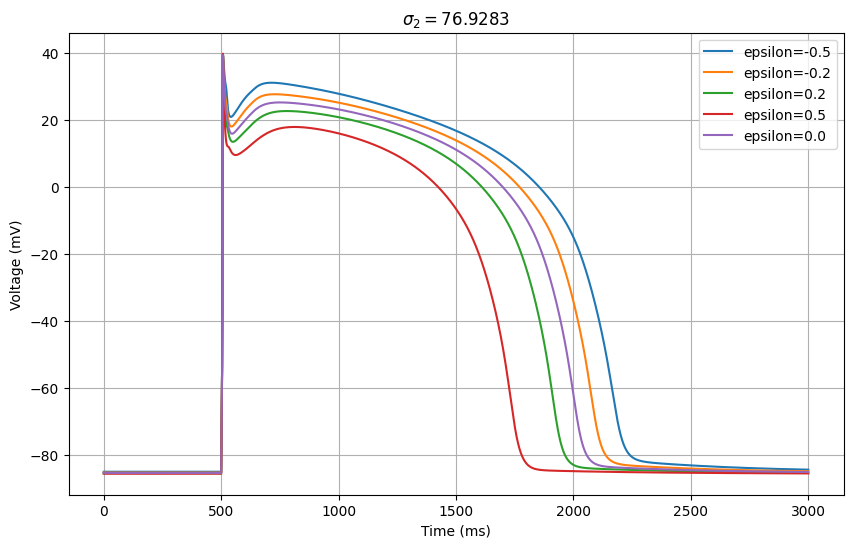

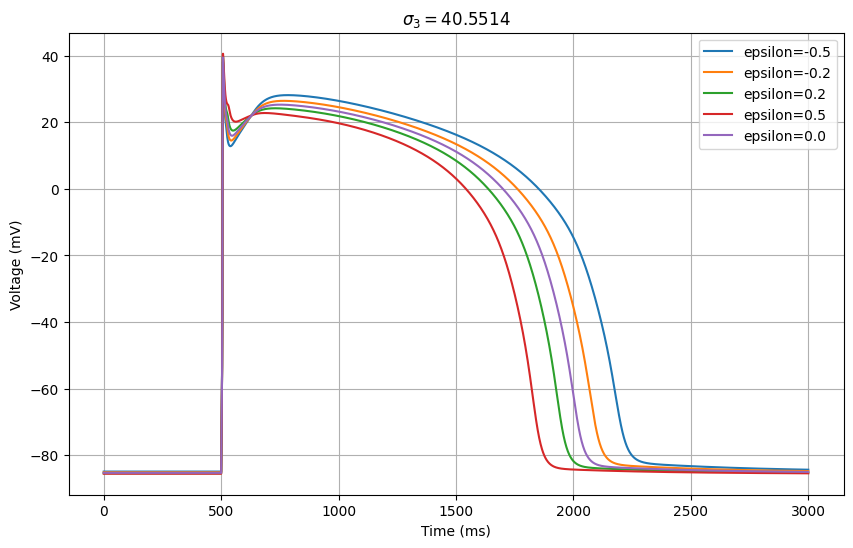

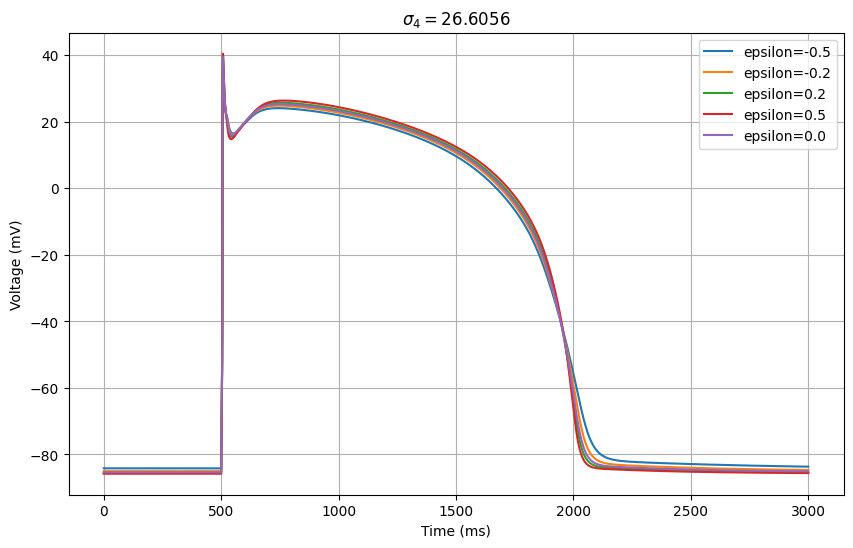

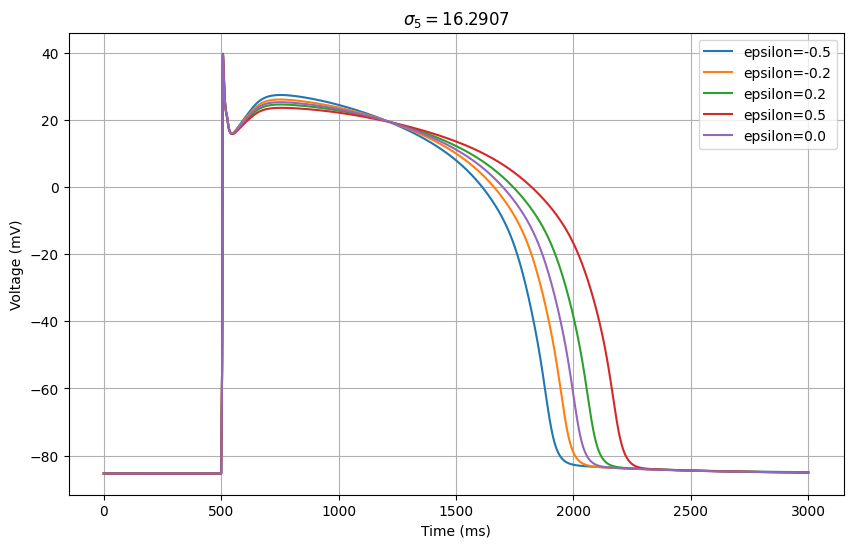

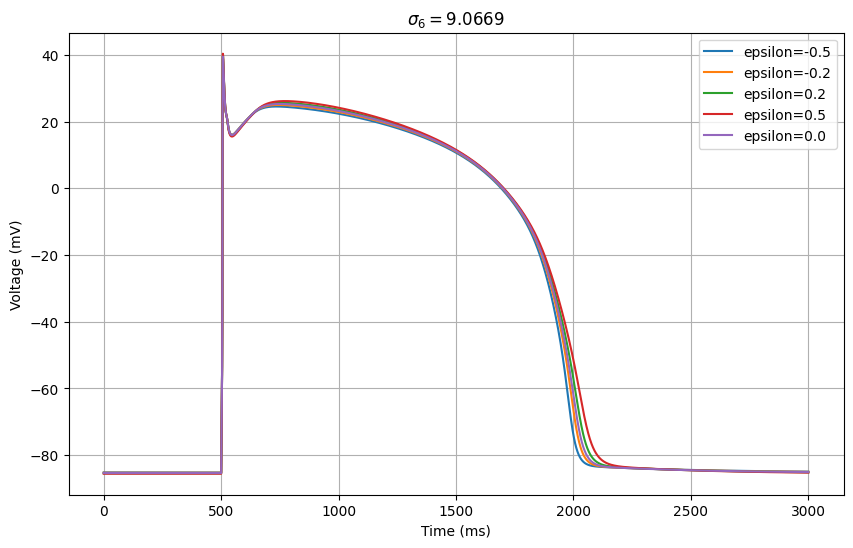

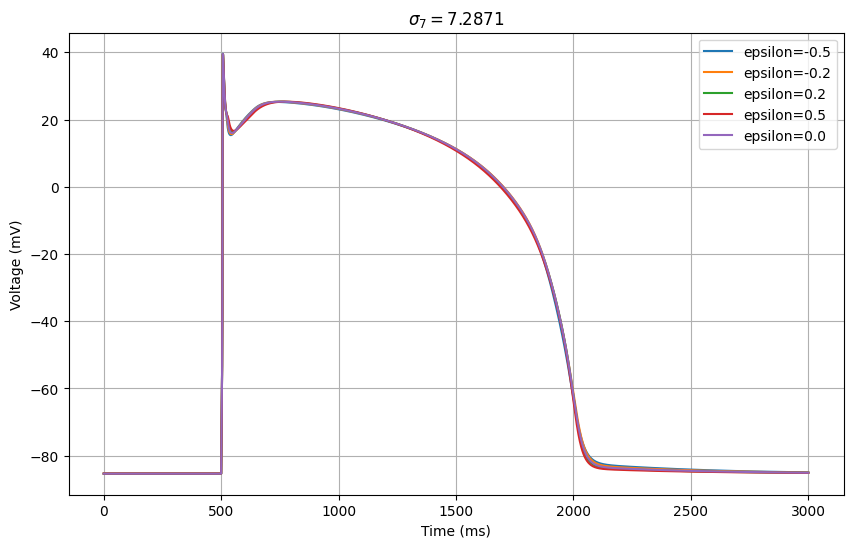

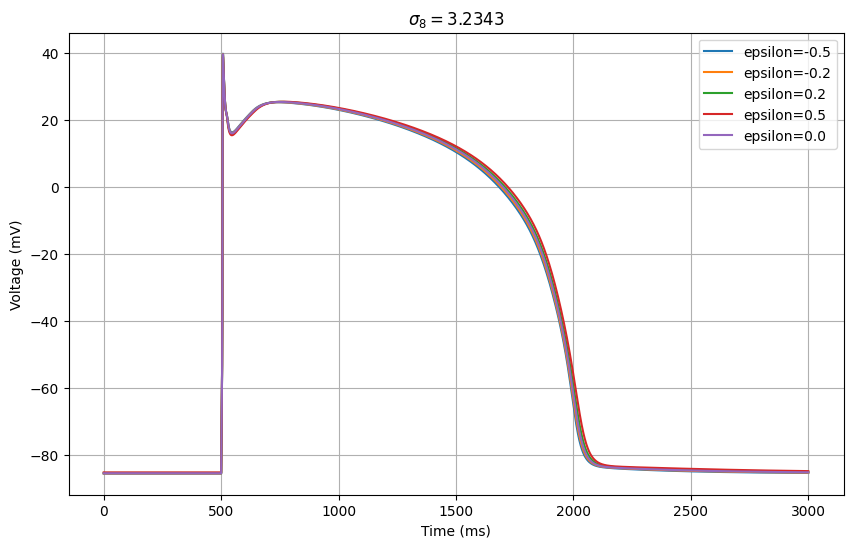

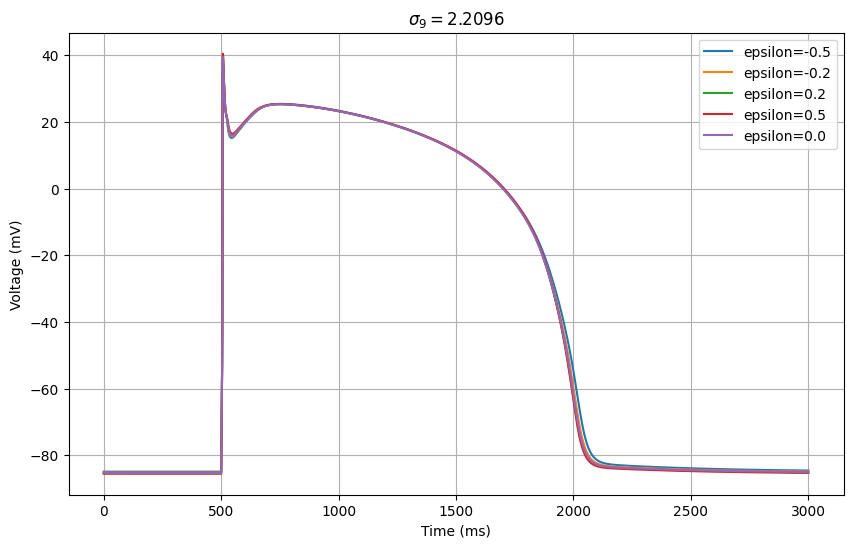

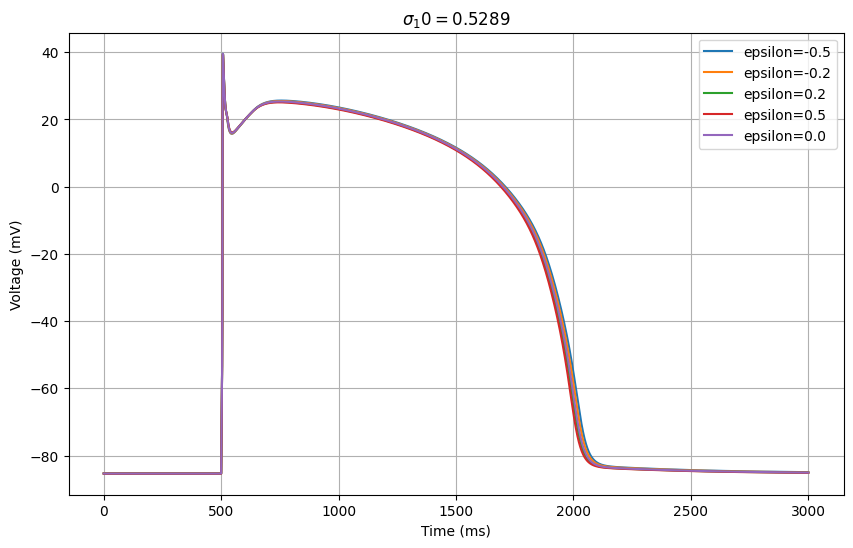

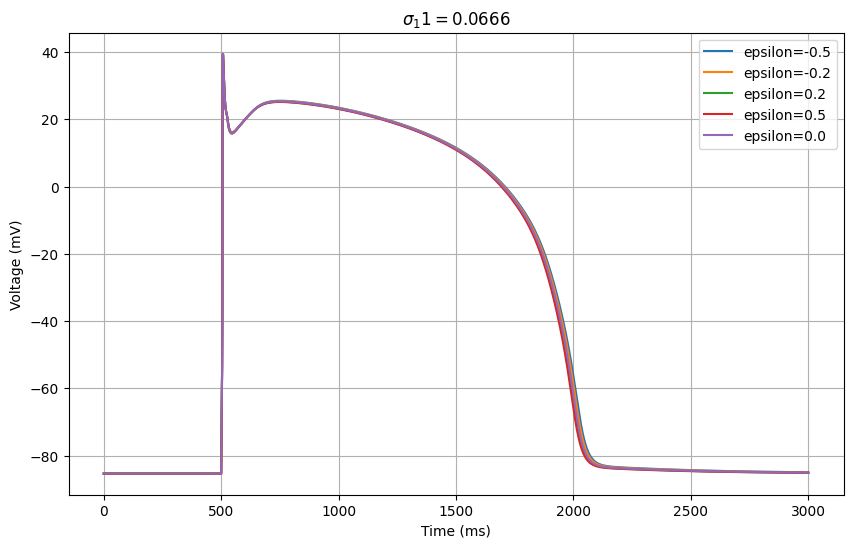

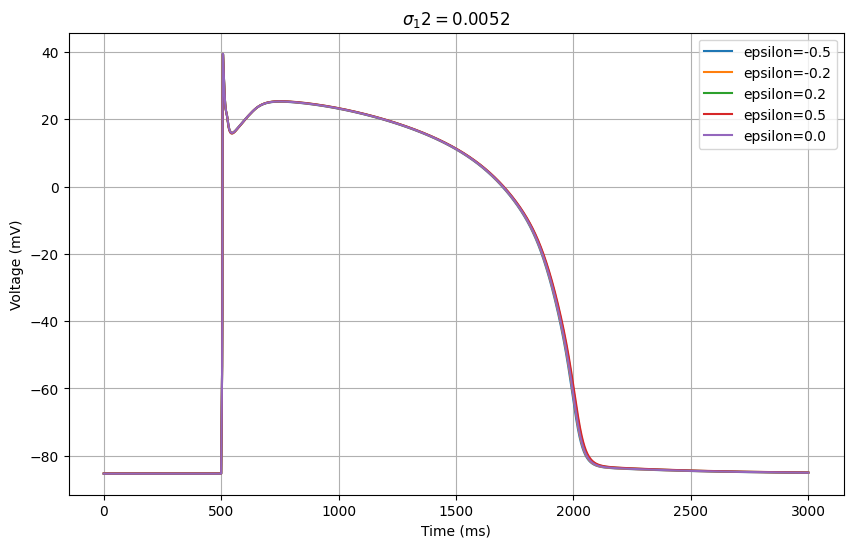

In [124]:
vec_lst = list(range(12))
epsilon_list = [-0.5,-0.2,0.2,0.5,0.0]
title_lst = S
V 
# title is "\epsilon = {title_lst[i]:.4f}" for vector i)
# for each vector, plot voltage for different epsilons
for vec in vec_lst:
    plt.figure(figsize=(10,6))
    for epsilon in epsilon_list:
        voltage = get_voltage(vec,epsilon)
        plt.plot(voltage, label=f"epsilon={epsilon}")
    plt.title(rf'$\sigma_{vec+1} = {title_lst[vec]:.4f}$')
    plt.xlabel("Time (ms)")
    plt.ylabel("Voltage (mV)")
    plt.legend()
    plt.grid()
    plt.show()

In [118]:
import matplotlib.pyplot as plt
import numpy as np

def plot(vec):
    # x positions labeled a–l
    labels = list("abcdefghijkl")
    x = np.arange(len(labels))

    fig, (ax, ax2) = plt.subplots(
        nrows=2, figsize=(5, 3.5),
        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.5}
    )
    # green rectangle background
    ax.axhspan(-1, 1, color='green', alpha=0.6)

    # black dots at y=0
    ax.plot(x, V[vec], 'ko', markersize=6,clip_on=False)
    ax.set_title(rf'$\sigma_{vec+1} = {title_lst[vec]:.4f}$')

    # axis settings
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_yticks([-1, 0, 1])
    ax.set_xlim(-1, len(labels)-0.5)
    ax.set_ylim(-1., 1.)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.grid(True,color = 'gray',linewidth = 2)
    
    styles = {
        -0.5: ('tab:blue', '-'),
        -0.2: ('#f4b942', '-'),  # custom yellowish
        0.2: ('#9b59b6', '-'),  # purple
        0.5: ('#ff6ec7', '-'),  # pink
        0.0: ('k', ':')         # black dotted
    }
    
    for epsilon in epsilon_list:
        voltage = get_voltage(vec,epsilon)
        # only plot 5/6 of voltage range
        voltage = voltage[:int(len(voltage)*5/6)]
        ax2.plot(np.arange(len(voltage))*0.2, voltage, label=f"ε={epsilon}",color = styles[epsilon][0],linestyle=styles[epsilon][1])
    ax2.set_xlabel("Time (ms)")
    ax2.grid()

    plt.show()

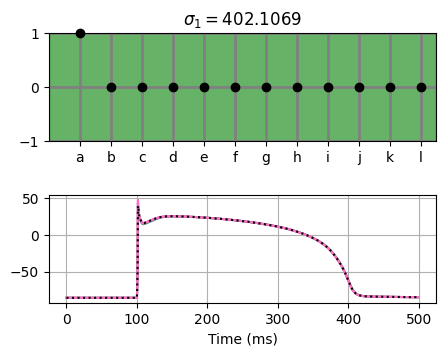

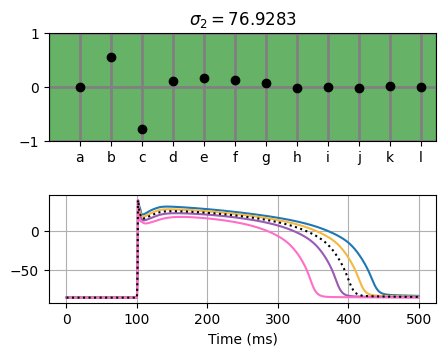

In [125]:
plot(0)
plot(1)

C:\Users\11061\AppData\Local\Temp\ipykernel_1160\703682222.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


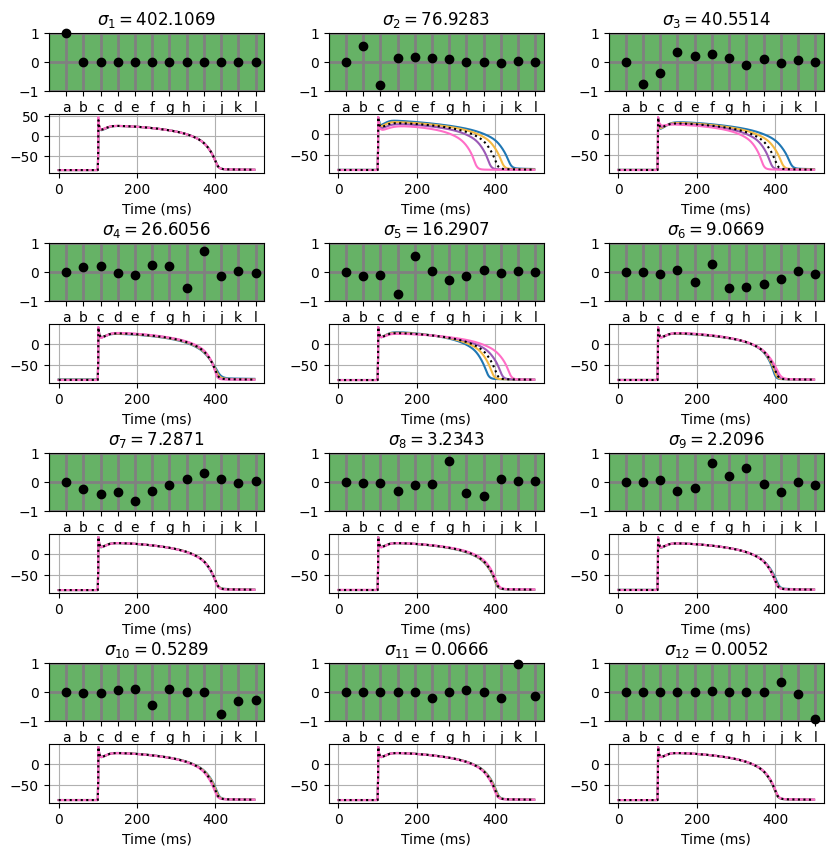

In [142]:
def plot(vec, fig=None, outer_spec=None):
    if fig is None:
        fig, (ax, ax2) = plt.subplots(
            nrows=2, figsize=(5, 3.5),
            gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.5}
        )
    else:
        # if called from wrapper, use external gridspec
        from matplotlib import gridspec
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer_spec, height_ratios=[1, 1], hspace=0.4
        )
        ax = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1])

    # -------------------- your original code (unchanged) --------------------
    labels = list("abcdefghijkl")
    x = np.arange(len(labels))

    # green rectangle background
    ax.axhspan(-1, 1, color='green', alpha=0.6)

    # black dots at y=0
    ax.plot(x, V[vec], 'ko', markersize=6, clip_on=False)
    ax.set_title(rf'$\sigma_{{{vec+1}}} = {title_lst[vec]:.4f}$')

    # axis settings
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_yticks([-1, 0, 1])
    ax.set_xlim(-1, len(labels)-0.5)
    ax.set_ylim(-1., 1.)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.grid(True, color='gray', linewidth=2)
    
    styles = {
        -0.5: ('tab:blue', '-'),
        -0.2: ('#f4b942', '-'),
         0.2: ('#9b59b6', '-'),
         0.5: ('#ff6ec7', '-'),
         0.0: ('k', ':')
    }
    
    for epsilon in epsilon_list:
        voltage = get_voltage(vec, epsilon)
        voltage = voltage[:int(len(voltage)*5/6)]
        ax2.plot(np.arange(len(voltage))*0.2, voltage,
                 label=f"ε={epsilon}",
                 color=styles[epsilon][0],
                 linestyle=styles[epsilon][1])

    ax2.set_xlabel("Time (ms)")
    ax2.grid()

    if fig is None:
        plt.show()
import matplotlib.pyplot as plt
from matplotlib import gridspec

fig = plt.figure(figsize=(10, 10))
outer = gridspec.GridSpec(4, 3, wspace=0.3, hspace=0.5)

for vec in range(12):
    plot(vec, fig=fig, outer_spec=outer[vec])

plt.tight_layout()
plt.savefig('replicate fig 1')
plt.show()


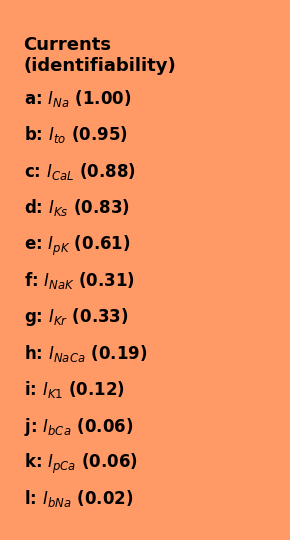

In [140]:
import matplotlib.pyplot as plt

# Currents and identifiability values (from Fig. 1)
currents = [
    r"$I_{Na}$", r"$I_{to}$", r"$I_{CaL}$", r"$I_{Ks}$", r"$I_{pK}$",
    r"$I_{NaK}$", r"$I_{Kr}$", r"$I_{NaCa}$", r"$I_{K1}$",
    r"$I_{bCa}$", r"$I_{pCa}$", r"$I_{bNa}$"
]
identifiability = [1.000, 0.954, 0.878, 0.827, 0.611, 0.308, 0.329, 0.191, 0.119, 0.064, 0.057, 0.022]
labels = list("abcdefghijkl")

# Create figure
fig, ax = plt.subplots(figsize=(3, 5.5))
ax.axis("off")

# Orange background (matches reference)
fig.patch.set_facecolor("#ff9966")

# Title
ax.text(0.05, 0.95, "Currents\n(identifiability)",
        fontsize=13, fontweight='bold', color='black', va='top')

# Each entry
for i, (label, current, idf) in enumerate(zip(labels, currents, identifiability)):
    y = 0.85 - i * 0.07
    text = f"{label}: {current} ({idf:.2f})"
    ax.text(0.05, y, text, fontsize=12, fontweight='bold', color='black', va='top')

plt.tight_layout()
plt.savefig('currents_identifiability.png', dpi=300)
plt.show()
